# Four in a Row

This analysis is only on the FEN variant. Models use a board representation inspired by Chess [Forsyth–Edwards_Notation](https://en.wikipedia.org/wiki/Forsyth–Edwards_Notation), and issue moves in format "m \<row\> \<col\>" on a 4(row)x9(col) board.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

from four_in_a_row import visualize_row_forest

In [2]:
df = pd.read_pickle('game_trees_df_annotated_preprocessed.pkl')
df.head(10)

,game_path,turn_idx,model,trees,extracted_move,move_success,max_ply,n_root_moves,n_leaf_moves,plan_area,...,search_effort,effort_p,model_names,trees_annotated,board_state,outcome,outcome_perspective,input_tokens,output_tokens,source
0,gpt-5-mini-high_vs_qwen3-next-thinking-vertex/...,12,"{'provider': 'openai', 'model': 'gpt-5-mini-20...","[[0,5, [0,6]], [1,3], [1,5]]",m 0 5,True,2.0,3.0,3.0,4.0,...,5.828427,1.5,gpt-5-mini-high,"[[0,5, [0,6]], [1,3], [1,5]]",FEN: 2WBB4/4W4/5W3/9\n\nCurrent player: Black ...,0.0,1.0,460.0,11155.0,False
1,gpt-5-mini-high_vs_qwen3-next-thinking-vertex/...,14,"{'provider': 'vertex', 'model': 'qwen/qwen3-ne...","[[3,6], [0,6], [1,3], [3,5]]",m 0 6,True,1.0,4.0,4.0,4.0,...,4.000000,1.5,qwen3-next-80b-a3b-thinking,"[[3,6], [0,6], [1,3], [3,5]]",FEN: 2WBBB3/4W4/5W3/9\n\nCurrent player: White...,0.0,0.0,593.0,5497.0,True
2,gpt-5-mini-high_vs_qwen3-next-thinking-vertex/...,16,"{'provider': 'openai', 'model': 'gpt-5-mini-20...","[[1,3], [1,5], [2,4]]",m 1 3,True,1.0,3.0,3.0,3.0,...,3.000000,1.5,gpt-5-mini-high,"[[1,3], [1,5], [2,4]]",FEN: 2WBBBW2/4W4/5W3/9\n\nCurrent player: Blac...,0.0,1.0,516.0,6227.0,False
3,gpt-5-mini-high_vs_qwen3-next-thinking-vertex/...,18,"{'provider': 'vertex', 'model': 'qwen/qwen3-ne...","[[3,6], [3,5], [3,4], [1,5], [3,3, [2,3]], [0,...",m 2 3,True,2.0,13.0,13.0,15.0,...,18.656854,1.5,qwen3-next-80b-a3b-thinking,"[[3,6], [3,5], [3,4], [1,5], [3,3, [2,3]], [0,...",FEN: 2WBBBW2/3BW4/5W3/9\n\nCurrent player: Whi...,0.0,0.0,648.0,11054.0,True
4,gpt-5-mini-high_vs_qwen3-next-thinking-vertex/...,20,"{'provider': 'openai', 'model': 'gpt-5-mini-20...","[[2,2, [3,1]], [3,1]]",m 2 2,True,2.0,2.0,2.0,3.0,...,4.828427,1.5,gpt-5-mini-high,"[[2,2, [3,1]], [3,1]]",FEN: 2WBBBW2/3BW4/3W1W3/9\n\nCurrent player: B...,0.0,1.0,574.0,7123.0,False
5,gpt-5-mini-high_vs_qwen3-next-thinking-vertex/...,22,"{'provider': 'vertex', 'model': 'qwen/qwen3-ne...","[[3,1]]",m 3 1,True,1.0,1.0,1.0,1.0,...,1.000000,1.5,qwen3-next-80b-a3b-thinking,"[[3,1]]",FEN: 2WBBBW2/3BW4/2BW1W3/9\n\nCurrent player: ...,0.0,0.0,705.0,3864.0,True
6,gpt-5-mini-high_vs_qwen3-next-thinking-vertex/...,24,"{'provider': 'openai', 'model': 'gpt-5-mini-20...","[[3,3], [1,1], [1,2], [3,5], [3,6]]",m 1 2,True,1.0,5.0,5.0,5.0,...,5.000000,1.5,gpt-5-mini-high,"[[3,3], [1,1], [1,2], [3,5], [3,6]]",FEN: 2WBBBW2/3BW4/2BW1W3/1W7\n\nCurrent player...,0.0,1.0,634.0,11731.0,False
7,gpt-5-mini-high_vs_qwen3-next-thinking-vertex/...,26,"{'provider': 'vertex', 'model': 'qwen/qwen3-ne...","[[3,2], [2,4, [2,6]], [2,1], [0,7], [0,8], [1,...",m 2 4,True,2.0,7.0,7.0,8.0,...,9.828427,1.5,qwen3-next-80b-a3b-thinking,"[[3,2], [2,4, [2,6]], [2,1], [0,7], [0,8], [1,...",FEN: 2WBBBW2/2BBW4/2BW1W3/1W7\n\nCurrent playe...,0.0,0.0,765.0,8142.0,True
8,gpt-5-mini-high_vs_qwen3-next-thinking-vertex/...,28,"{'provider': 'openai', 'model': 'gpt-5-mini-20...","[[0,2], [0,6], [2,1], [2,6]]",m 2 6,True,1.0,4.0,4.0,4.0,...,4.000000,1.5,gpt-5-mini-high,"[[(0,2, illegal)], [(0,6, illegal)], [2,1], [2...",FEN: 2WBBBW2/2BBW4/2BWWW3/1W7\n\nCurrent playe...,0.0,1.0,693.0,5459.0,False
9,gpt-5-mini-high_vs_qwen3-next-thinking-vertex/...,30,"{'provider': 'vertex', 'model': 'qwen/qwen3-ne...","[[3,4], [3,6], [1,5], [3,5], [3,3], [3,2], [3,...",m 3 4,True,1.0,15.0,15.0,15.0,...,15.000000,1.5,qwen3-next-80b-a3b-thinking,"[[3,4], [3,6], [1,5], [3,5], [3,3], [3,2], [3,...",FEN: 2WBBBW2/2BBW4/2BWWWB2/1W7\n\nCurrent play...,0.0,0.0,825.0,11750.0,True


In [3]:
# calculate mean search effort per model
model_stats = df.groupby('model_names').agg({
    'move_success': 'mean',
    'max_ply': 'mean',
    'n_root_moves': 'mean',
    'total_nodes': 'mean',
    'expansions': 'mean'
}).reset_index()

# # add ratings to the dataframe
df_outcome = df.groupby(['game_path', 'model_names'])['outcome_perspective'].mean().reset_index().groupby(['model_names'])['outcome_perspective'].mean().reset_index()

model_stats['rating'] = model_stats['model_names'].map(
    df_outcome.set_index('model_names')['outcome_perspective']
)

# calculate search effort
# model_stats['log_search_effort'] = np.log(model_stats['search_effort'] + 1)
model_stats['log_search_effort'] = np.log(model_stats['total_nodes'] + 1)

# add source
def open_source(model_name):
    open_source_keys = ['deepseek', 'glm', 'kimi', 'llama', 'qwen', 'oss']

    for key in open_source_keys:
        if key in model_name:
            return True
    
    return False

sources = [open_source(model_name) for model_name in model_stats['model_names']]
model_stats['source'] = sources

model_stats

,model_names,move_success,max_ply,n_root_moves,total_nodes,expansions,rating,log_search_effort,source
0,claude-opus-4.1,0.998623,1.271350,2.928375,3.369146,0.440771,0.543269,1.474568,False
1,claude-sonnet-4,0.987603,1.446281,3.734160,4.716253,0.982094,0.668269,1.743314,False
2,claude-sonnet-4.5,0.994143,1.417277,3.748170,4.560761,0.812592,0.557692,1.715735,False
3,deepseek-r1,0.990654,2.320427,6.156208,10.778371,4.628838,0.586538,2.466265,True
4,deepseek-v3.1,0.960118,1.076809,2.265879,2.387001,0.121123,0.326923,1.219945,True
5,deepseek-v3.1-thinking,0.993557,2.007732,6.287371,9.344072,3.056701,0.557692,2.336414,True
6,deepseek-v3.2-thinking,0.998705,2.233161,6.506477,10.593264,4.089378,0.687500,2.450424,True
7,gemini-2.5-pro,0.992604,1.877219,2.878698,4.433432,1.554734,0.567308,1.692571,False
8,glm-4.5-thinking,0.899660,1.096939,3.698980,3.933673,0.234694,0.163462,1.596084,True
9,glm-4.6,0.903581,3.475207,6.066116,18.663912,12.699725,0.350962,2.978785,True


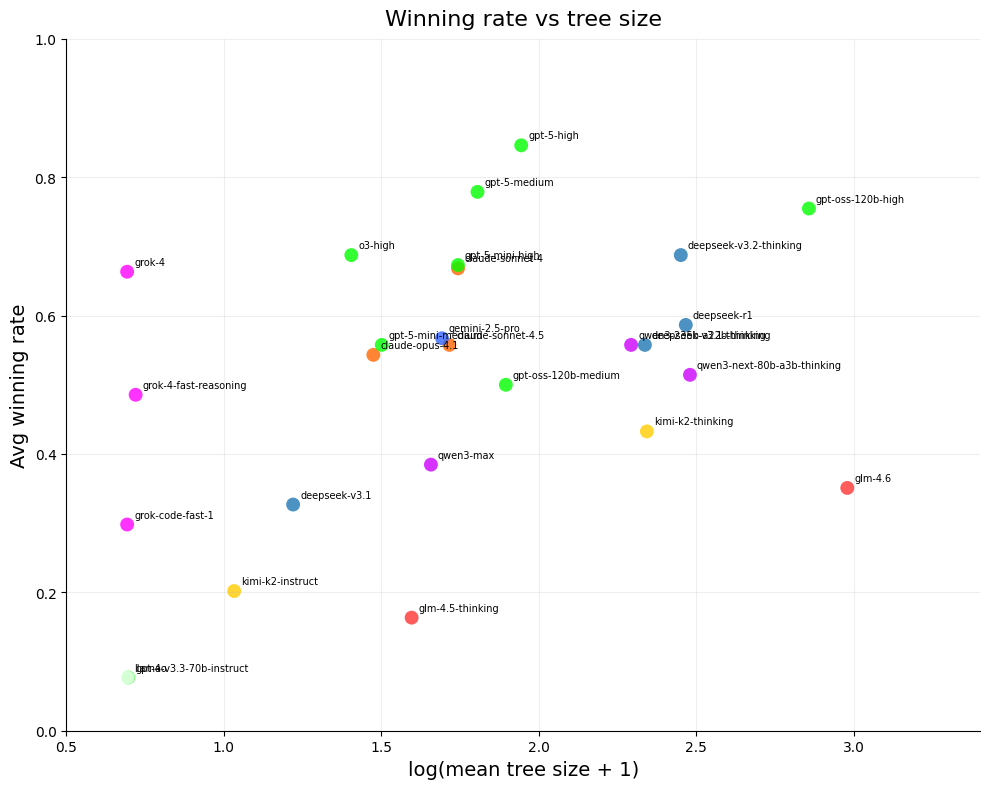

In [4]:
def model_to_color(model_name):
    name = model_name.lower()

    if 'gpt' in name or 'o3' in name:
        return '#00ff00'
    elif 'deepseek' in name:
        return '#1f77b4'
    elif 'qwen' in name:
        return '#cc00ff'
    elif 'claude' in name:
        return '#ff6600'
    elif 'kimi' in name:
        return '#ffcc00'
    elif 'glm' in name:
        return '#ff3333'
    elif 'grok' in name:
        return '#ff00ff'
    elif 'gemini' in name:
        return '#3366ff'
    elif 'llama' in name:
        return '#ffffff'
    else:
        return "#545353"

plt.figure(figsize = (10, 8))
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

# plot points
colors = [model_to_color(m) for m in model_stats['model_names']]
plt.scatter(model_stats['log_search_effort'], model_stats['rating'], c = colors, s = 100, alpha = 0.8, edgecolors = 'none')

# add labels for each point
for idx, row in model_stats.iterrows():
    plt.annotate(row['model_names'], (row['log_search_effort'], row['rating']), xytext = (5, 5), textcoords = 'offset points', fontsize = 7)
    
# labels and title
plt.ylim(0, 1)
plt.xlim(0.5, 3.4)
plt.xlabel('log(mean tree size + 1)', fontsize = 14)
plt.ylabel('Avg winning rate', fontsize = 14)
plt.title('Winning rate vs tree size', fontsize = 16, pad = 10)
plt.grid(True, alpha = 0.2)
plt.tight_layout()
plt.savefig('figures/performance_vs_search_effort.pdf', facecolor='#444444')
plt.show()

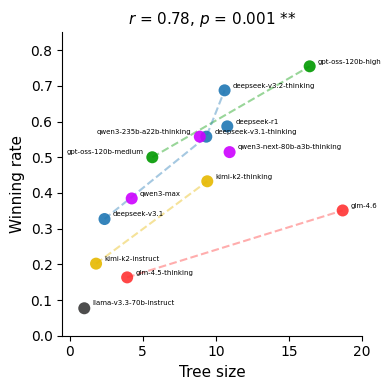

In [20]:
from scipy.stats import pearsonr

def model_to_color(model_name):
    name = model_name.lower()

    if 'gpt' in name or 'o3' in name:
        return '#009900'
    elif 'deepseek' in name:
        return '#1f77b4'
    elif 'qwen' in name:
        return '#cc00ff'
    elif 'claude' in name:
        return '#ff6600'
    elif 'kimi' in name:
        return '#e6b800'
    elif 'glm' in name:
        return '#ff3333'
    elif 'grok' in name:
        return '#ff00ff'
    elif 'gemini' in name:
        return '#3366ff'
    elif 'llama' in name:
        return "#3A3939"
    else:
        return "#3A3939"

model_stats_open = model_stats[model_stats['source'] == True]

r, p = pearsonr(model_stats_open['log_search_effort'], model_stats_open['rating'])
sig = '**' if p < 0.01 else ('*' if p < 0.05 else ('.' if p < 0.1 else ''))

plt.figure(figsize = (4, 4))
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

# plot points
colors = [model_to_color(m) for m in model_stats_open['model_names']]
plt.scatter(model_stats_open['total_nodes'], model_stats_open['rating'], c = colors, s = 75, alpha = 0.9, edgecolors = 'none')

# manual offsets for specific labels
manual_offsets = {
    'qwen3-235b-a22b-thinking': (-74, 2),
    'gpt-oss-120b-medium': (-62, 2),
}

# add labels for each point
for idx, row in model_stats_open.iterrows():
    offset = manual_offsets.get(row['model_names'], (6, 2))
    plt.annotate(row['model_names'], (row['total_nodes'], row['rating']), xytext = offset, textcoords = 'offset points', fontsize = 5)

# Define line groups: (color, list of model names in order)
line_groups = [
    ('#009900', ['gpt-oss-120b-medium', 'gpt-oss-120b-high']),
    ('#1f77b4', ['deepseek-v3.1', 'deepseek-v3.1-thinking', 'deepseek-v3.2-thinking']),
    ('#e6b800', ['kimi-k2-instruct', 'kimi-k2-thinking']),
    ('#ff3333', ['glm-4.5-thinking', 'glm-4.6']),
]

# Build lookup: model_name -> (x, y)
model_coords = {row['model_names']: (row['total_nodes'], row['rating'])
                for _, row in model_stats.iterrows()}

for color, group in line_groups:
    xs = [model_coords[m][0] for m in group if m in model_coords]
    ys = [model_coords[m][1] for m in group if m in model_coords]
    plt.plot(xs, ys, color = color, linestyle = '--', linewidth = 1.5, alpha = 0.4, zorder = 0)

# plt.xscale('log')
# plt.xticks([1, 10, 50])
plt.xlim(-0.5, 20)
plt.ylim(0, 0.85)
plt.xlabel('Tree size', fontsize = 11)
plt.ylabel('Winning rate', fontsize = 11)
plt.title(rf'$r$ = {r:.2f}, $p$ = {p:.3f} {sig}', fontsize = 11)
plt.tight_layout()
plt.savefig('figures/performance_vs_search_effort_open_source.pdf', facecolor='white')
plt.show()

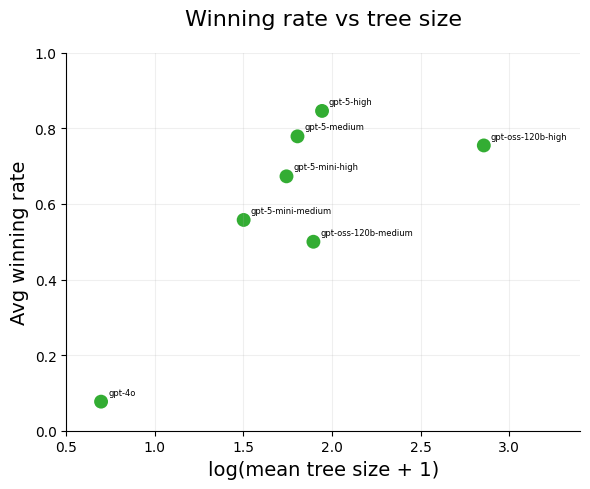

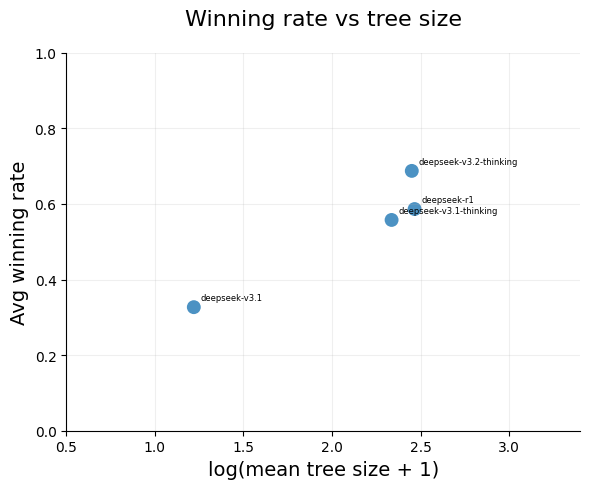

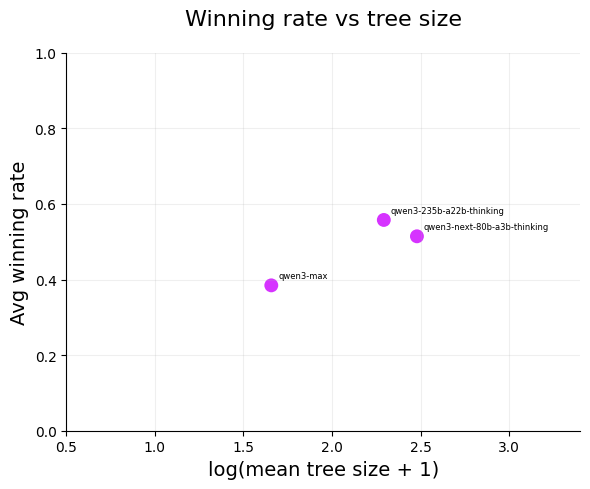

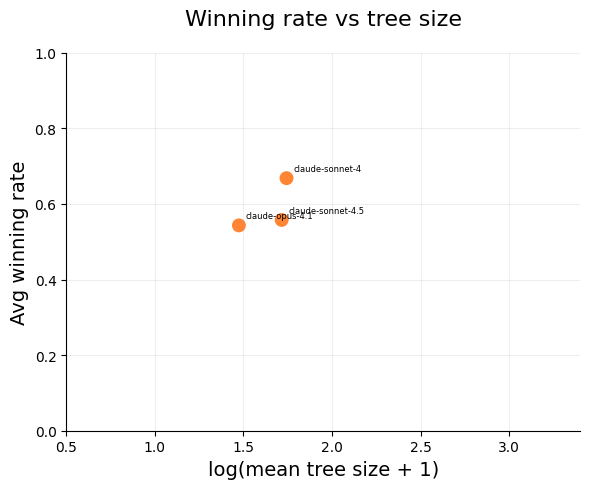

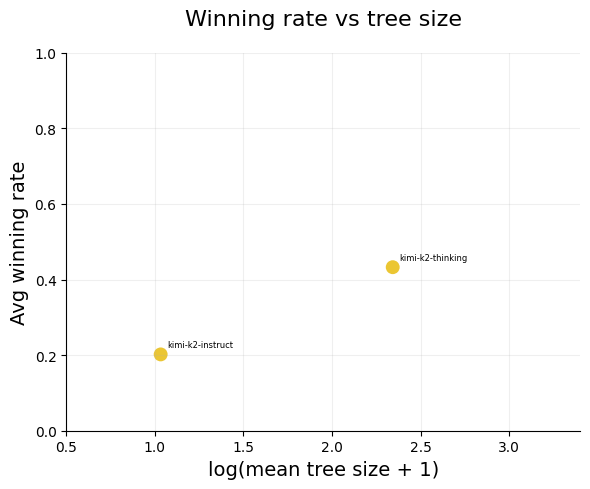

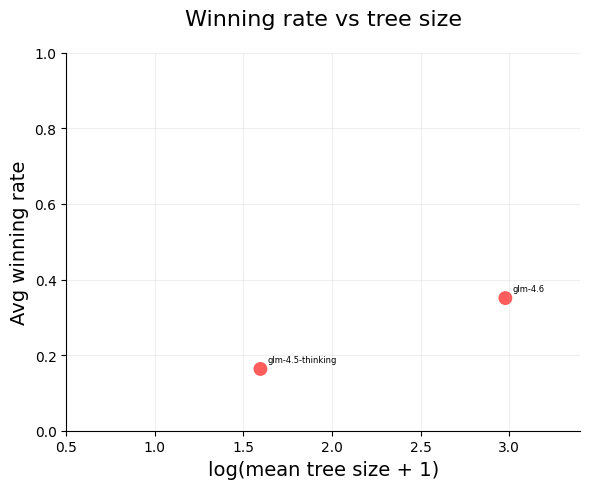

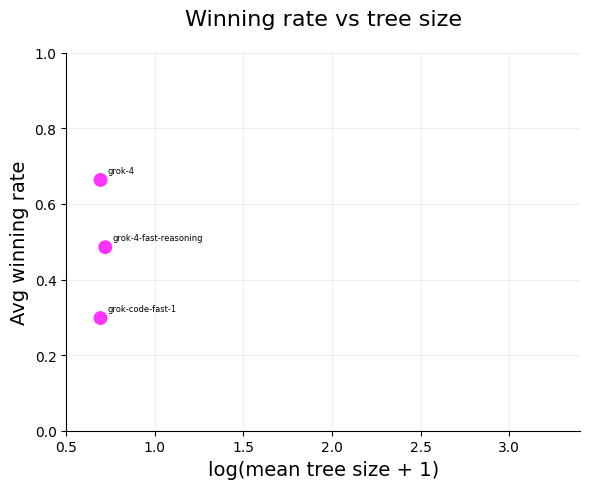

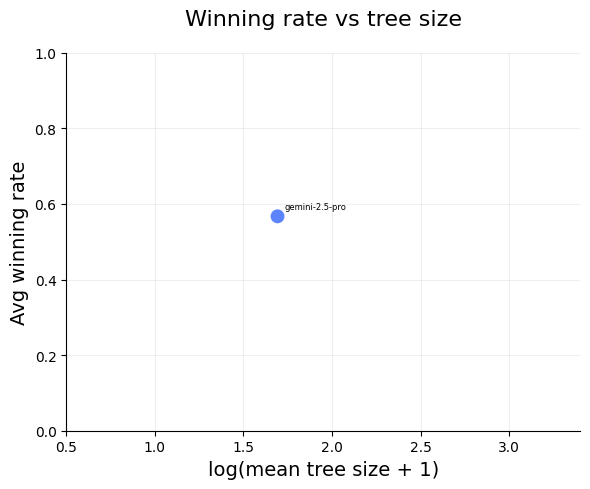

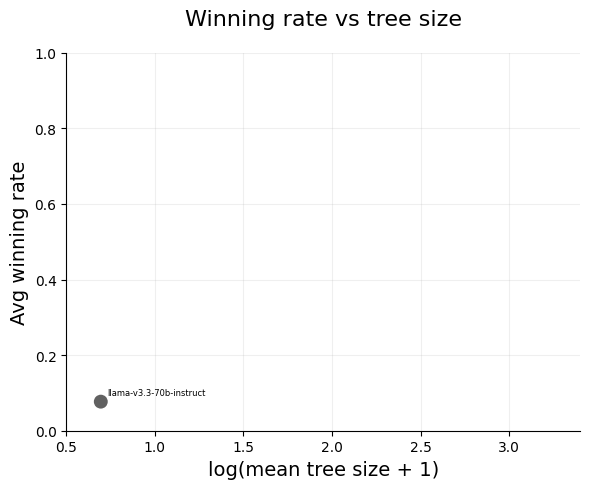

In [6]:
model_classes = ['gpt', 'deepseek', 'qwen', 'claude', 'kimi', 'glm', 'grok', 'gemini', 'llama']

for i, model_class in enumerate(model_classes):
    plt.figure(figsize = (6, 5))
    plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

    class_stats = model_stats[model_stats['model_names'].str.contains(model_class)]

    # plot points
    colors = [model_to_color(m) for m in class_stats['model_names']]
    plt.scatter(class_stats['log_search_effort'], class_stats['rating'], c = colors, s = 100, alpha = 0.8, edgecolors = 'none')

    # add labels for each point
    for idx, row in class_stats.iterrows():
        plt.annotate(row['model_names'], (row['log_search_effort'], row['rating']), xytext = (5, 5), textcoords = 'offset points', fontsize = 6)

    # labels and title
    plt.ylim(0, 1)
    plt.xlim(0.5, 3.4)
    plt.xlabel('log(mean tree size + 1)', fontsize = 14)
    plt.ylabel('Avg winning rate', fontsize = 14)
    plt.title('Winning rate vs tree size', fontsize = 16, pad = 20)
    plt.grid(True, alpha = 0.2)
    plt.tight_layout()
    plt.savefig(f'figures/performance_vs_search_effort_{model_class}.pdf', facecolor='#444444')
    plt.show()

In [7]:
from scipy.stats import pearsonr

r, p = pearsonr(model_stats['log_search_effort'], model_stats['rating'])

print('Pearson r:', r)
print('p-value:', p)

Pearson r: 0.44671030336396833
p-value: 0.019496352136987107


In [8]:
r, p = pearsonr(model_stats_open['log_search_effort'], model_stats_open['rating'])

print('Pearson r:', r)
print('p-value:', p)

Pearson r: 0.7831124168581363
p-value: 0.0009247397184942821


In [9]:
# Compute max and mean of per-turn max_ply per model
ply_stats = df.groupby('model_names')['max_ply'].agg(['max', 'mean']).reset_index()
ply_stats.columns = ['model_names', 'max_max_ply', 'mean_max_ply']

model_stats = model_stats.merge(ply_stats, on='model_names', how='left')
model_stats[['model_names', 'max_max_ply', 'mean_max_ply', 'rating']]

,model_names,max_max_ply,mean_max_ply,rating
0,claude-opus-4.1,5.0,1.271350,0.543269
1,claude-sonnet-4,5.0,1.446281,0.668269
2,claude-sonnet-4.5,5.0,1.417277,0.557692
3,deepseek-r1,6.0,2.320427,0.586538
4,deepseek-v3.1,4.0,1.076809,0.326923
5,deepseek-v3.1-thinking,6.0,2.007732,0.557692
6,deepseek-v3.2-thinking,8.0,2.233161,0.687500
7,gemini-2.5-pro,6.0,1.877219,0.567308
8,glm-4.5-thinking,3.0,1.096939,0.163462
9,glm-4.6,16.0,3.475207,0.350962


In [10]:
df = pd.read_pickle('game_trees_df_annotated_preprocessed.pkl')

In [11]:
len(df[df['source'] == True]['game_path'].unique())

1092